In [3]:
# Task1: Import Modules
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch import optim,nn
from time import time

In [5]:
# Task 2: Create a Transformation
normalized = transforms.Normalize((0.5,),(0.5,))
tensor = transforms.ToTensor()
transformation = transforms.Compose([tensor,normalized])


In [9]:
# Task 3: Download and Load Datasets
training_dataset = datasets.MNIST('/bytefiles', download=True, train=True, transform=transformation)
testing_dataset = datasets.MNIST('/bytefiles', download=True, train=False, transform=transformation)

train_data = torch.utils.data.DataLoader(training_dataset, batch_size=64, shuffle=True)
test_data = torch.utils.data.DataLoader(testing_dataset, batch_size=64, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



1.7%

100.0%


Extracting /bytefiles/MNIST/raw/train-images-idx3-ubyte.gz to /bytefiles/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

...

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting /bytefiles/MNIST/raw/t10k-images-idx3-ubyte.gz to /bytefiles/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting /bytefiles/MNIST/raw/t10k-labels-idx1-ubyte.gz to /bytefiles/MNIST/raw



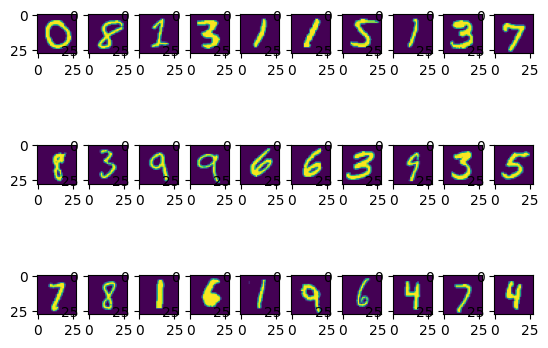

In [10]:
# Task 4: Visualize Images
images,labels = iter(train_data).next()
for i in range(1,31):
    plt.subplot(3,10,i)
    plt.subplots_adjust(wspace=0.3)
    plt.imshow(images[i].numpy().squeeze())

In [11]:
# Task 5: Calculate Size of Layers
input_layer = 784
hidden_layer1 = 64
hidden_layer2 = 32
output_layer = 10

In [12]:
# Task 6: Build a Model
model = nn.Sequential(nn.Linear(input_layer,hidden_layer1),
nn.ReLU(),
nn.Linear(hidden_layer1,hidden_layer2),
nn.ReLU(),
nn.Linear(hidden_layer2,output_layer))

In [13]:
# Task 7: Calculate Cross-Entropy Loss
images = images.view(images.shape[0],-1)
outputs = model(images)
lossFunction = nn.CrossEntropyLoss()
loss = lossFunction(outputs,labels)


In [14]:
# Task 8: Obtain the Stochastic Gradient Descent Optimizer
gradient_descent = optim.SGD(model.parameters(),lr=0.1)

In [15]:
# Task 9: Train the Model
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for images,labels in train_data:
        images = images.view(images.shape[0],-1)
        #feed-forward
        gradient_descent.zero_grad()
        loss = lossFunction(model(images),labels)
        #Back Propogation
        loss.backward()
        #Optimize the weights
        gradient_descent.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(labels)
    print("Iteration : ", epoch+1, end="\t")
    print("Loss: ", epoch_loss)
    


Iteration :  1	Loss:  904.321132324636
Iteration :  2	Loss:  366.43363056331873
Iteration :  3	Loss:  272.6942418720573
Iteration :  4	Loss:  230.14552486874163
Iteration :  5	Loss:  198.55171176232398
Iteration :  6	Loss:  175.3273328943178
Iteration :  7	Loss:  160.71260253852233
Iteration :  8	Loss:  144.84517282247543
Iteration :  9	Loss:  129.26036205282435
Iteration :  10	Loss:  123.49616755871102
Iteration :  11	Loss:  114.25345721689519
Iteration :  12	Loss:  105.63655543792993
Iteration :  13	Loss:  97.0309780635871
Iteration :  14	Loss:  94.24396711145528
Iteration :  15	Loss:  86.92372970387805
Iteration :  16	Loss:  84.09529218694661
Iteration :  17	Loss:  76.66914440202527
Iteration :  18	Loss:  74.58537334932771
Iteration :  19	Loss:  66.50734789008857
Iteration :  20	Loss:  66.7326296424726


In [18]:
# Task 10: Get the Predicted Label
def get_predicted_label(image):
    image = image.view(1,28*28)
    with torch.no_grad():
        prediction_score = model(image)
    return np.argmax(prediction_score)

images,labels = next(iter(test_data))
print("Predicted Label: ",
get_predicted_label(images[0]))
print("Actual Label: ", labels.numpy()[0])

Predicted Label:  tensor(2)
Actual Label:  2


In [19]:
# Task 11: Test the Model
totalCount = 0
accurateCount = 0
for images, labels in test_data:
    for i in range(len(labels)):
        predictedLabel = get_predicted_label(images[i])
        actualLabel = labels.numpy()[i]
        print("Predicted Label: ",predictedLabel," / Actual Label: ", actualLabel)
        if(predictedLabel == actualLabel):
            accurateCount+=1
    totalCount += len(labels)

print("Total images tested: :",totalCount)
print("Accurate predictions: ",accurateCount)
print("Accuracy percentage: ",((accurateCount/totalCount)*100), "%")

Predicted Label:  tensor(4)  / Actual Label:  4
Predicted Label:  tensor(5)  / Actual Label:  5
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(9)  / Actual Label:  9
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(5)  / Actual Label:  5
Predicted Label:  tensor(7)  / Actual Label:  7
Predicted Label:  tensor(7)  / Actual Label:  7
Predicted Label:  tensor(6)  / Actual Label:  6
Predicted Label:  tensor(5)  / Actual Label:  5
Predicted Label:  tensor(3)  / Actual Label:  3
Predicted Label:  tensor(7)  / Actual Label:  7
Predicted Label:  tensor(8)  / Actual Label:  8
Predicted Label:  tensor(0)  / Actual Label:  0
Predicted Label:  tensor(3)  / Actual Label:  3
Predicted Label:  tensor(4)  / Actual Label:  4
Predicted Label:  tensor(1)  / Actual Label:  1
Predicted Label:  tensor(1)  / Actual Label:  1
Predicted Label:  tensor(4)  / Actual Label:  4
Predicted Label:  tensor(0)  / Actual Label:  0
Predicted Label:  tensor(6)  / Actual La